Loaded 10 documents.
Loading Pretrained Sentence Transformer (all-MiniLM-L6-v2)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings Shape: (10, 384)
Clustering into 3 topics...

--- Clustering Results ---

Cluster 0:
['The new movie is awesome' 'Cinematography in this film is great'
 'The director shot the scene perfectly']

Cluster 1:
['The cat sits outside' 'The dog barks at the stranger'
 'Felines are independent animals' 'Puppies are adorable']

Cluster 2:
['A man is playing guitar' 'Music is my life' 'He loves playing the piano']

Silhouette Score: 0.1562


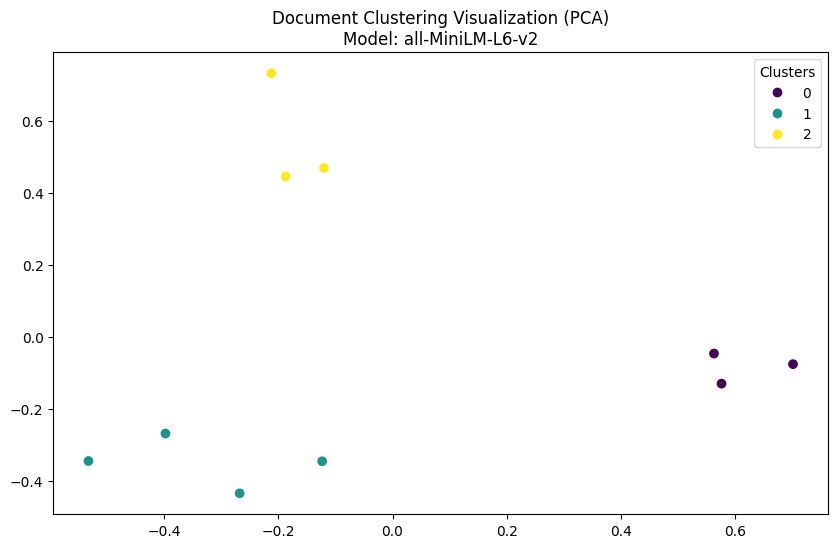

In [1]:


!pip install sentence-transformers --quiet

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Data Preparation ---
# A small corpus of text documents about different topics
documents = [
    "The cat sits outside",
    "A man is playing guitar",
    "The new movie is awesome",
    "The dog barks at the stranger",
    "Music is my life",
    "Cinematography in this film is great",
    "Felines are independent animals",
    "He loves playing the piano",
    "The director shot the scene perfectly",
    "Puppies are adorable"
]
print(f"Loaded {len(documents)} documents.")

# --- 2. LLM Embedding Generation ---
# Using a small, efficient BERT model
print("Loading Pretrained Sentence Transformer (all-MiniLM-L6-v2)...")
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(documents)

print("Embeddings Shape:", embeddings.shape)

# --- 3. Clustering ---
num_clusters = 3
print(f"Clustering into {num_clusters} topics...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

# --- 4. Analysis ---
# Map labels back to docs
df = pd.DataFrame({'Document': documents, 'Cluster': labels})
print("\n--- Clustering Results ---")
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    print(df[df['Cluster'] == i]['Document'].values)

# --- 5. Evaluation ---
sil_score = silhouette_score(embeddings, labels)
print(f"\nSilhouette Score: {sil_score:.4f}")

# --- 6. Visualization (PCA) ---
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_features[:,0], reduced_features[:,1], c=labels, cmap='viridis')
plt.title(f'Document Clustering Visualization (PCA)\nModel: all-MiniLM-L6-v2')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()